In [ ]:
!pip install librosa soundfile scikit-learn numpy

In [ ]:
!wget https://www.openslr.org/resources/101/speechocean762.tar.gz

--2026-06-04 17:23:04--  https://www.openslr.org/resources/101/speechocean762.tar.gz
Resolving www.openslr.org (www.openslr.org)... 136.243.171.4
Connecting to www.openslr.org (www.openslr.org)|136.243.171.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 520810923 (497M) [application/x-gzip]
Saving to: ‘speechocean762.tar.gz’

speechocean762.tar. 100%[===================>] 496.68M  25.3MB/s    in 36s     

2026-06-04 17:23:40 (13.8 MB/s) - ‘speechocean762.tar.gz’ saved [520810923/520810923]



In [ ]:
import tarfile

tar_path = "/content/speechocean762.tar.gz"

with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall("/content/data")

print("Dataset extracted successfully")

/tmp/ipykernel_655/1193552579.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/data")


Dataset extracted successfully


In [ ]:
import os
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

In [ ]:
N_MFCC = 13
N_COMPONENTS = 64 # Increased GMM components for better modeling
IVECTOR_DIM = 256 # Increased i-vector dimension for better speaker discrimination

In [ ]:
DATASET_PATH = "/content/data/speechocean762"

audio_files = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.lower().endswith(".wav"):

            full_path = os.path.join(root, file)

            audio_files.append(full_path)

print("Total wav files:", len(audio_files))

Total wav files: 5245


In [ ]:
audio_files= sorted(audio_files)
train_files= audio_files[:2500]
test_files= audio_files[2500:5000]
print("Train:",len(train_files))
print("Test:",len(test_files))


Train: 2500
Test: 2500


In [ ]:

train_features = []

for file in train_files:

    try:

        audio, sr = librosa.load(
            file,
            sr=16000
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=N_MFCC,
        )
        mfcc = mfcc.T
        mfcc= (mfcc- np.mean(mfcc,axis=0))/(np.std(mfcc, axis=0)+ 1e-8)

        train_features.append(mfcc)

    except Exception as e:

        print("Error:", file)

train_features = np.vstack(train_features)

print("MFCC shape:", train_features.shape)

MFCC shape: (281172, 13)


In [ ]:
gmm = GaussianMixture(
    n_components=N_COMPONENTS,
    covariance_type='diag',
    max_iter=100, # Increased max_iter for better convergence
    random_state=42
)

gmm.fit(train_features)

print("GMM trained successfully")

GMM trained successfully


### Populate Utterance Statistics (N, F_super)

In [ ]:
utternaces_stats = []

for file_path in train_files:
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        # Normal MFCC (13 dims)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC).T
        mfcc = (mfcc - np.mean(mfcc, axis=0)) / (np.std(mfcc, axis=0) + 1e-8)

        gamma = gmm.predict_proba(mfcc)
        N = gamma.sum(axis=0)
        F = gamma.T @ mfcc
        F_centered = (F - N[:, None] * gmm.means_)
        F_super = F_centered.flatten()

        utternaces_stats.append({"N": N, "F_super": F_super})
    except Exception as e:
        continue

print(f"Collected stats for {len(utternaces_stats)} utterances.")

Collected stats for 2500 utterances.


In [ ]:
import numpy as np

# Assuming feature_dim is N_MFCC, and GMM parameters are available from 'gmm'
feature_dim = N_MFCC # Defined in SbBOqv-5MvPk

# Initialize T and Sigma_inv if not already done
# T is the Total Variability matrix
if 'T' not in globals() or T.shape != (feature_dim * N_COMPONENTS, IVECTOR_DIM):
    T = np.random.randn(feature_dim * N_COMPONENTS, IVECTOR_DIM) * 0.01 # Random initialization

# Sigma_inv is the inverse of the diagonal covariance matrix from GMM
if 'Sigma_inv' not in globals() or Sigma_inv.shape != gmm.covariances_.shape:
    Sigma_inv = 1 / gmm.covariances_

max_iterations = 30
tolerance = 1e-4

for iteration in range(max_iterations):
    A_sum = np.zeros((feature_dim * N_COMPONENTS, IVECTOR_DIM))
    C_sum = np.zeros((IVECTOR_DIM, IVECTOR_DIM))

    for stats in utternaces_stats:
        N = stats['N']
        F_super = stats['F_super']

        N_diag = np.repeat(N, feature_dim)
        # Corrected: Flatten Sigma_inv to ensure it's a 1D array of correct dimensions for element-wise multiplication
        Sigma_inv_flat = Sigma_inv.flatten()

        # Ensure Sigma_inv_flat is correctly shaped for diagonal matrix multiplication
        # The term (np.diag(N_diag * Sigma_inv_flat)) will create a (feature_dim * N_COMPONENTS, feature_dim * N_COMPONENTS) diagonal matrix

        # Calculate L_i (covariance matrix of the i-vector for current utterance)
        L_i = np.eye(IVECTOR_DIM) + T.T @ (np.diag(N_diag * Sigma_inv_flat)) @ T
        L_i_inv = np.linalg.inv(L_i)

        # Calculate w_hat (expected i-vector for this utterance)
        w_hat = L_i_inv @ T.T @ (np.diag(N_diag * Sigma_inv_flat)) @ F_super

        # Accumulate A (sum of F_super_i * w_hat_i^T)
        A_sum += np.outer(F_super, w_hat)

        # Accumulate C (sum of E[w_i * w_i^T]) where E[w_i * w_i^T] = L_i_inv + w_hat_i * w_hat_i^T
        C_sum += (L_i_inv + np.outer(w_hat, w_hat))

    T_new = A_sum @ np.linalg.pinv(C_sum) # Use pseudo-inverse for stability

    diff = np.linalg.norm(T_new - T)

    print(
        f"Iteration {iteration+1}, Change={diff:.6f}"
    )

    T = T_new

    if diff < tolerance:
        print(
            f"Converged after {iteration+1} iterations"
        )
        break

Iteration 1, Change=6.207977
Iteration 2, Change=3.025246
Iteration 3, Change=1.475133
Iteration 4, Change=0.986444
Iteration 5, Change=0.786579
Iteration 6, Change=0.690366
Iteration 7, Change=0.638776
Iteration 8, Change=0.609675
Iteration 9, Change=0.592170
Iteration 10, Change=0.581212
Iteration 11, Change=0.574047
Iteration 12, Change=0.569226
Iteration 13, Change=0.565896
Iteration 14, Change=0.563546
Iteration 15, Change=0.561853
Iteration 16, Change=0.560607
Iteration 17, Change=0.559674
Iteration 18, Change=0.558964
Iteration 19, Change=0.558419
Iteration 20, Change=0.558000
Iteration 21, Change=0.557681
Iteration 22, Change=0.557443
Iteration 23, Change=0.557271
Iteration 24, Change=0.557153
Iteration 25, Change=0.557082
Iteration 26, Change=0.557047
Iteration 27, Change=0.557043
Iteration 28, Change=0.557064
Iteration 29, Change=0.557105
Iteration 30, Change=0.557160


In [ ]:
import os
import numpy as np
import librosa # Re-adding import in case of kernel issues

output_dir = '/content/ivectors'
os.makedirs(output_dir, exist_ok=True)
final_ivectors = []
final_files = []

# Ensure feature_dim is defined in this scope as it was defined locally in a previous cell
feature_dim = N_MFCC # N_MFCC is globally available from cell SbBOqv-5MvPk

for file in train_files:
    try:
        audio, sr = librosa.load(file, sr=16000)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC).T
        mfcc = (mfcc - np.mean(mfcc, axis=0)) / (np.std(mfcc, axis=0) + 1e-8)

        gamma = gmm.predict_proba(mfcc)
        N = gamma.sum(axis=0)
        F_super = (gamma.T @ mfcc - N[:, None] * gmm.means_).flatten()

        # Corrected: Use the flattened inverse covariance matrix for the diagonal matrix
        N_diag = np.repeat(N, feature_dim)
        # The term `(1 / gmm.covariances_).flatten()` correctly gets the 1D array of inverse covariances
        diag_matrix_content = N_diag * (1 / gmm.covariances_).flatten()

        L = np.eye(IVECTOR_DIM) + T.T @ np.diag(diag_matrix_content) @ T
        w = np.linalg.solve(L, T.T @ np.diag(diag_matrix_content) @ F_super)

        # Length Normalization
        norm = np.linalg.norm(w)
        if norm > 0: w /= norm

        final_ivectors.append(w)
        final_files.append(file)
    except Exception as e:
        # Uncomment the line below for debugging if needed to see specific errors
        # print(f"Error processing file {file}: {e}")
        continue

all_ivectors = np.array(final_ivectors)
print(f"Extracted {all_ivectors.shape[0]} i-vectors of dimension {all_ivectors.shape[1]}")

# Generate speaker_ids here after final_files is fully populated
speaker_ids = []
for file in final_files:
    speaker_id = file.split("/")[-2]
    speaker_ids.append(speaker_id)
print(f"Generated speaker_ids for {len(speaker_ids)} i-vectors.")

Extracted 2500 i-vectors of dimension 256
Generated speaker_ids for 2500 i-vectors.


### Prepare Ratings for Visualization

To visualize the i-vectors with their corresponding quality scores, we need to extract the `total_score` from the `scores.json` file and create a `ratings` array. This array will be aligned with the `all_ivectors` that were generated.

In [ ]:
import json
with open("/content/data/speechocean762/resource/scores.json",'r') as f:
  scores= json.load(f)
for k,v in list(scores.items())[:3]:
  print(k)
  print(v)
  print()

000010011
{'accuracy': 8, 'completeness': 10.0, 'fluency': 9, 'prosodic': 9, 'words': [{'accuracy': 10, 'stress': 10, 'phones': ['W', 'IY0'], 'total': 10, 'text': 'WE', 'phones-accuracy': [2.0, 2.0]}, {'accuracy': 10, 'stress': 10, 'phones': ['K', 'AO0', 'L'], 'total': 10, 'text': 'CALL', 'phones-accuracy': [2.0, 1.8, 1.8]}, {'accuracy': 10, 'stress': 10, 'phones': ['IH0', 'T'], 'total': 10, 'text': 'IT', 'phones-accuracy': [2.0, 2.0]}, {'accuracy': 6, 'stress': 10, 'phones': ['B', 'EH0', 'R'], 'total': 6, 'text': 'BEAR', 'phones-accuracy': [2.0, 1.0, 1.0]}], 'total': 8, 'text': 'WE CALL IT BEAR'}

000010035
{'accuracy': 8, 'completeness': 10.0, 'fluency': 9, 'prosodic': 9, 'words': [{'accuracy': 8, 'stress': 10, 'phones': ['Z', 'IH1', 'R', 'OW0'], 'total': 7, 'text': 'ZERO', 'phones-accuracy': [2.0, 1.4, 1.4, 2.0]}, {'accuracy': 8, 'stress': 10, 'phones': ['TH', 'R', 'IY0'], 'total': 8, 'text': 'THREE', 'phones-accuracy': [1.2, 2.0, 2.0]}, {'accuracy': 10, 'stress': 10, 'phones': ['F'

In [ ]:
import os
print(os.listdir('/content/data/speechocean762'))

['WAVE', 'resource', '.gitignore', 'README.md', 'train', 'test']


In [ ]:
import os
print(os.listdir('/content/data/speechocean762/resource'))

['scores-detail.json', 'text-phone', 'scores.json', 'lexicon.txt']


In [ ]:
print(audio_files[:10])

['/content/data/speechocean762/WAVE/SPEAKER0001/000010011.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010035.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010053.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010063.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010069.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010075.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010089.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010095.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010106.WAV', '/content/data/speechocean762/WAVE/SPEAKER0001/000010113.WAV']


In [ ]:
print(list(scores.keys())[:10])

['000010011', '000010035', '000010053', '000010063', '000010069', '000010075', '000010089', '000010095', '000010106', '000010113']


In [ ]:
total_scores=[]
for file in audio_files[:len(all_ivectors)]:

  utt_id= file.split("/")[-1].replace(".WAV","")

  score= scores[utt_id]
  total=(
      score["accuracy"]+
      score["completeness"]+
      score["fluency"]+
      score["prosodic"]
  )/4
  total_scores.append(total)

print(total_scores[:10])

[9.0, 9.0, 9.75, 9.5, 9.5, 9.25, 9.5, 9.5, 9.0, 8.25]


The previous code block filtered `all_ivectors` and `speaker_ids` to create `filtered_ivectors` and `filtered_speakers` containing data only for the top 3 unique speakers. This `filtered_ivectors` dataset is then used for PCA dimensionality reduction to 2 components, enabling visualization of these speaker clusters.

The speaker IDs were extracted from the file paths to associate each i-vector with its corresponding speaker. This logic has been moved to a point where all dependencies are met for better consistency.

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# Filter i-vectors for the top 3 unique speakers
unique_speakers = sorted(
    list(set(speaker_ids))
)

selected_speakers = unique_speakers[:3]

filtered_ivectors = []
filtered_speakers = []

for ivector, speaker in zip(
        all_ivectors,
        speaker_ids):

    if speaker in selected_speakers:

        filtered_ivectors.append(ivector)
        filtered_speakers.append(speaker)

filtered_ivectors = np.array(
    filtered_ivectors
)

print(f"Filtered i-vectors shape: {filtered_ivectors.shape}")
print(f"Number of speakers selected: {len(set(filtered_speakers))}")

pca = PCA(
    n_components=2,
    random_state=42
)

ivectors_2d = pca.fit_transform(
    filtered_ivectors
)

print(f"PCA transformed i-vectors shape: {ivectors_2d.shape}")

Filtered i-vectors shape: (60, 256)
Number of speakers selected: 3
PCA transformed i-vectors shape: (60, 2)


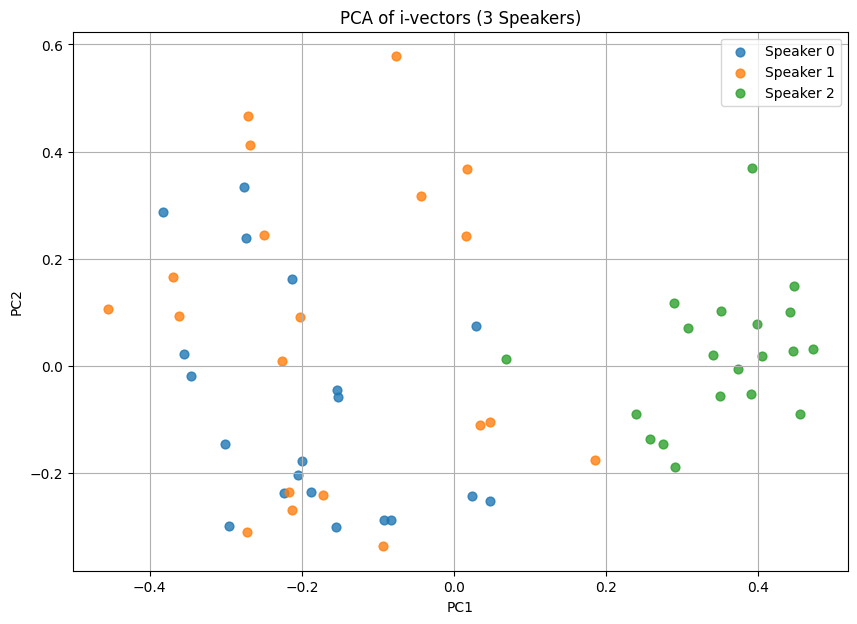

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

speaker_labels = encoder.fit_transform(
    filtered_speakers
)

plt.figure(figsize=(10,7))

for speaker in np.unique(speaker_labels):

    idx = speaker_labels == speaker

    plt.scatter(
        ivectors_2d[idx,0],
        ivectors_2d[idx,1],
        s=40,
        alpha=0.8,
        label=f"Speaker {speaker}"
    )

plt.title(
    "PCA of i-vectors (3 Speakers)"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend()

plt.grid(True)

plt.show()